In [1]:
import qiskit
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino

from qiskit.visualization import plot_histogram



# Define Main Paths, Constants

In [2]:
MAX_HOPS = 2
MIN_HOPS = 1
NUM_SHOTS = 1024
OPTIMIZATION_LEVEL = 1

In [3]:
# The nodes of the network
node_names = [0, 1, 2, 3, 4, 5]

# =============================================================================
# FIXED PHYSICAL QUBIT MAPPING
# =============================================================================
# Each network node is assigned to specific physical qubits on FakeFez.
# This ensures consistent noise characteristics across all runs:
# - Node X always uses the same physical qubits regardless of circuit structure
# - When Node X is absent from a circuit, its physical qubits are NOT used by other nodes
#
# Each node needs 9 qubits for the [[5,1,3]] code:
#   - Qubits 0-4: Data + Encoding qubits (the 5 code qubits)
#   - Qubits 5-8: Ancilla qubits for syndrome measurement

NODE_PHYSICAL_QUBITS = {
    0: list(range(0, 9)),      # Node 0 → physical qubits 0-8
    1: list(range(9, 18)),     # Node 1 → physical qubits 9-17
    2: list(range(18, 27)),    # Node 2 → physical qubits 18-26
    3: list(range(27, 36)),    # Node 3 → physical qubits 27-35
    4: list(range(36, 45)),    # Node 4 → physical qubits 36-44
    5: list(range(45, 54)),    # Node 5 → physical qubits 45-53
}

# Physical qubits for path/channel registers (1 qubit per edge for swapping)
PATH_PHYSICAL_QUBITS = {
    (0, 1): [54,55],
    (0, 3): [56],
    (1, 2): [57,58],
    (1, 4): [59],
    (2, 5): [60],
    (3, 4): [61,62],
    (4, 5): [63,64],
}

# PATH_PHYSICAL_QUBITS = {
#     (0, 1): [54],
#     (0, 3): [55],
#     (1, 2): [56],
#     (1, 4): [57],
#     (2, 5): [58],
#     (3, 4): [59],
#     (4, 5): [60],
# }

# Total physical qubits needed: 54 (nodes) + 7 (paths) = 61
TOTAL_QUBITS = len(NODE_PHYSICAL_QUBITS)*9 + sum(len(q) for q in PATH_PHYSICAL_QUBITS.values())

print("Node to Physical Qubit Mapping:")
for node, qubits in NODE_PHYSICAL_QUBITS.items():
    print(f"  Node {node}: physical qubits {qubits[0]}-{qubits[-1]}")
print(f"\nPath Register Physical Qubits: {PATH_PHYSICAL_QUBITS}")
print(f"Total physical qubits used: {TOTAL_QUBITS}")

Node to Physical Qubit Mapping:
  Node 0: physical qubits 0-8
  Node 1: physical qubits 9-17
  Node 2: physical qubits 18-26
  Node 3: physical qubits 27-35
  Node 4: physical qubits 36-44
  Node 5: physical qubits 45-53

Path Register Physical Qubits: {(0, 1): [54, 55], (0, 3): [56], (1, 2): [57, 58], (1, 4): [59], (2, 5): [60], (3, 4): [61, 62], (4, 5): [63, 64]}
Total physical qubits used: 65


In [4]:
# =============================================================================
# NOISE MODEL SETUP (Decoupled from Coupling Constraints)
# =============================================================================
# We extract ONLY the noise model from FakeFez (T1, T2, gate errors, readout errors)
# but do NOT enforce its coupling map. This means:
#   - We get realistic per-qubit noise characteristics
#   - We can connect any qubits we want (no topology constraints)
#   - Physical qubit indices determine which noise profile is applied

fake_backend = FakeFez()
# fake_backend = FakeTorino()
network_channel_noise = NoiseModel.from_backend(fake_backend)

# CRITICAL: FakeFez basis gates - circuits MUST be decomposed to these for noise to apply
# The noise model only has error definitions for these gates!
FEZ_BASIS_GATES = ['cz', 'id', 'rz', 'sx', 'x']

print(f"Noise Model extracted from {fake_backend}")
print(f"  Backend qubits: {fake_backend.num_qubits}")
print(f"  Noise model basis gates: {network_channel_noise.basis_gates}")
print(f"  Gates with noise defined: {network_channel_noise.noise_instructions}")
print(f"\nIMPORTANT: Circuits must be transpiled to basis gates: {FEZ_BASIS_GATES}")
print(f"  SWAP gates will be decomposed to CZ + SX gates for proper noise application")

Noise Model extracted from <qiskit_ibm_runtime.fake_provider.backends.fez.fake_fez.FakeFez object at 0x111079d30>
  Backend qubits: 156
  Noise model basis gates: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Gates with noise defined: ['cz', 'id', 'measure', 'reset', 'sx', 'x']

IMPORTANT: Circuits must be transpiled to basis gates: ['cz', 'id', 'rz', 'sx', 'x']
  SWAP gates will be decomposed to CZ + SX gates for proper noise application


In [5]:
# Verify the physical qubit assignments
print("Physical Qubit Assignments Summary:")
print("-" * 50)
for node in node_names:
    qubits = NODE_PHYSICAL_QUBITS[node]
    print(f"Node {node}: qubits {qubits[0]:2d}-{qubits[-1]:2d} (data={qubits[4]}, ancillas={qubits[5:9]})")

Physical Qubit Assignments Summary:
--------------------------------------------------
Node 0: qubits  0- 8 (data=4, ancillas=[5, 6, 7, 8])
Node 1: qubits  9-17 (data=13, ancillas=[14, 15, 16, 17])
Node 2: qubits 18-26 (data=22, ancillas=[23, 24, 25, 26])
Node 3: qubits 27-35 (data=31, ancillas=[32, 33, 34, 35])
Node 4: qubits 36-44 (data=40, ancillas=[41, 42, 43, 44])
Node 5: qubits 45-53 (data=49, ancillas=[50, 51, 52, 53])


In [6]:
# Verify path register assignments
print("\nPath Register Assignments:")
print("-" * 50)
for edge, qubits in PATH_PHYSICAL_QUBITS.items():
    print(f"Edge {edge}: path qubit(s) = {qubits}")


Path Register Assignments:
--------------------------------------------------
Edge (0, 1): path qubit(s) = [54, 55]
Edge (0, 3): path qubit(s) = [56]
Edge (1, 2): path qubit(s) = [57, 58]
Edge (1, 4): path qubit(s) = [59]
Edge (2, 5): path qubit(s) = [60]
Edge (3, 4): path qubit(s) = [61, 62]
Edge (4, 5): path qubit(s) = [63, 64]


{(0, 1): 1, (1, 2): 1, (0, 3): 1, (1, 4): 1, (2, 5): 1, (3, 4): 1, (4, 5): 1}


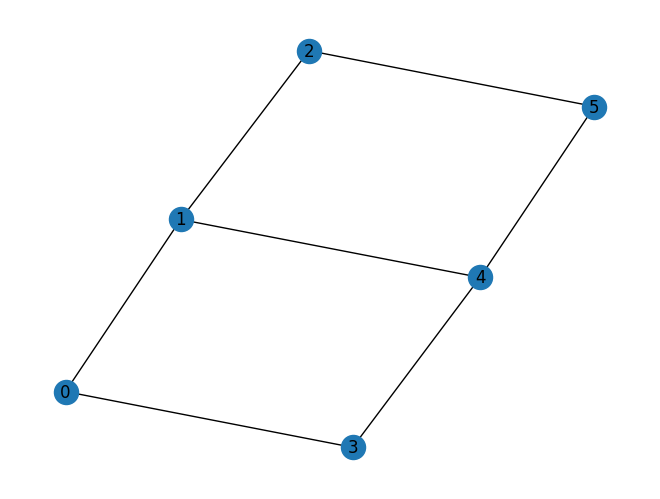

In [7]:
import networkx as nx

network_graph = nx.Graph()
network_graph.add_nodes_from(node_names)
network_graph.add_edges_from([(0, 1), (1, 2), (0, 3), (1, 4), (2, 5), (3, 4), (4, 5)])
nx.draw(network_graph, with_labels=True)

swaps_per_edge = {
    (0, 1): 1,
    (1, 2): 1,
    (0, 3): 1,
    (1, 4): 1,
    (2, 5): 1,
    (3, 4): 1,
    (4, 5): 1
}
print(swaps_per_edge)

In [8]:
# Multi-hop paths:
from itertools import combinations
ALL_HOP_PATHS = []
for pairs in combinations(node_names, 2):
    multi_hop_paths = nx.all_simple_paths(network_graph, source=pairs[0], target=pairs[1], cutoff=MAX_HOPS)
    ALL_HOP_PATHS.extend([x for x in multi_hop_paths if len(x) > MIN_HOPS])

print("All multi-hop paths:", ALL_HOP_PATHS)

All multi-hop paths: [[0, 1], [0, 1, 2], [0, 3], [0, 1, 4], [0, 3, 4], [1, 2], [1, 0, 3], [1, 4, 3], [1, 4], [1, 2, 5], [1, 4, 5], [2, 1, 4], [2, 5, 4], [2, 5], [3, 4], [3, 4, 5], [4, 5]]


# Encoding Circuit

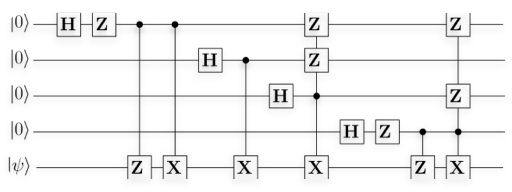

Testing circuit with correction at source
Building circuit for path: [0, 1, 2]
  Source: Node 0 (physical qubits 0-8)
  Sink: Node 2 (physical qubits 18-26)
  Swap edges: [(0, 1), (1, 2)]

Circuit created with 65 qubits, 4 classical bits
Gate counts: OrderedDict({'swap': 30, 'cz': 14, 'h': 12, 'cx': 12, 'measure': 4, 'z': 2, 'barrier': 2, 'x': 1})


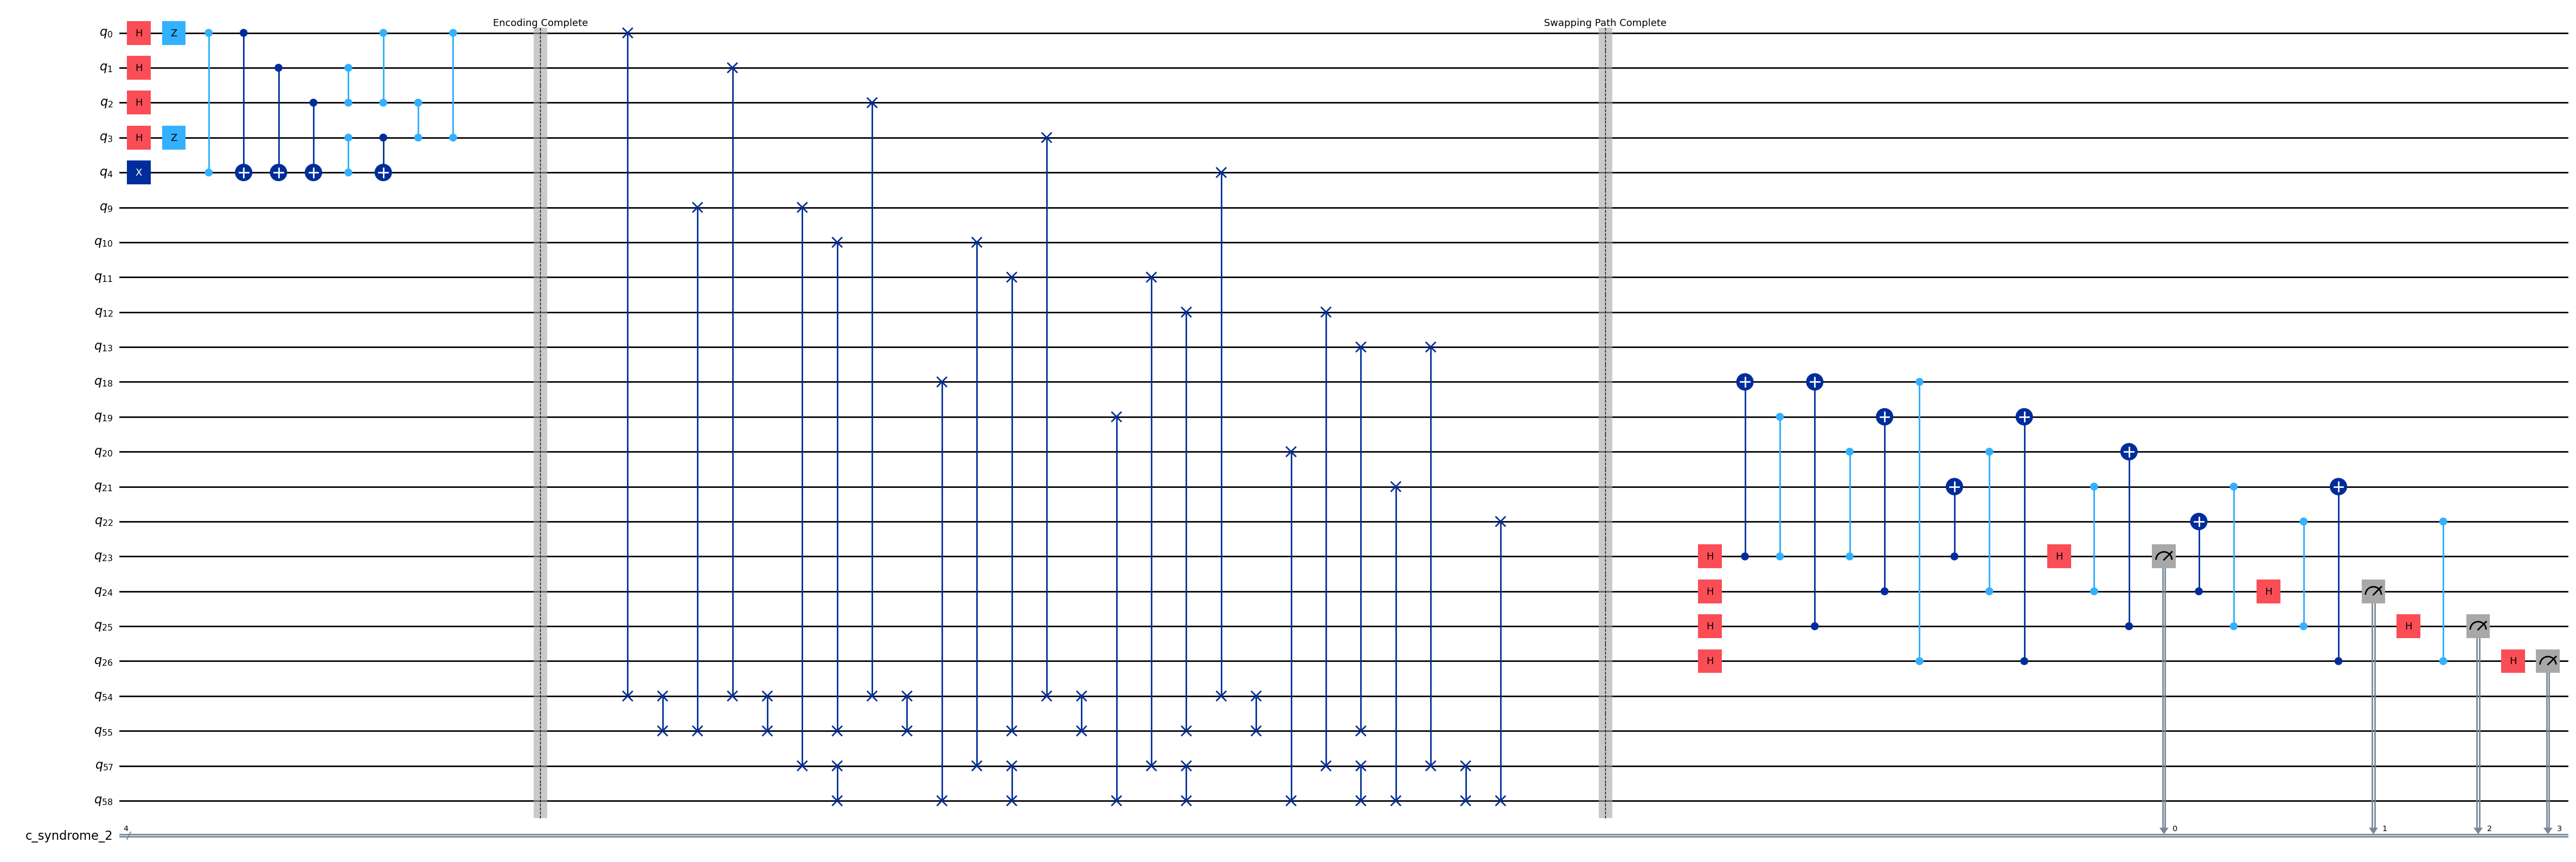

In [9]:
# =============================================================================
# CIRCUIT BUILDING HELPER FUNCTIONS (Using Physical Qubits Directly)
# =============================================================================
# These functions build circuits using physical qubit indices from NODE_PHYSICAL_QUBITS.
# This ensures consistent qubit-to-noise mapping across all runs.
#
# [[5,1,3]] Code Structure:
#   - 5 data qubits (indices 0-4 within node)
#   - 4 ancilla qubits for syndrome measurement (indices 5-8 within node)
#   - 4 stabilizers: XZZXI, IXZZX, XIXZZ, ZXIXZ

# Stabilizer definitions for [[5,1,3]] code
STABILIZERS = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]

# Syndrome-to-correction lookup table for [[5,1,3]] code
# Syndrome bits ordered [g1, g2, g3, g4] (ancilla indices 5,6,7,8)
# Correction tuple: (qubit_index, pauli_operator) or None for no error
SYNDROME_TO_CORRECTION = {
    0:  None,        # No error
    1:  (0, 'X'),    # X error on qubit 0  - syndrome 0001
    2:  (2, 'Z'),    # Z error on qubit 2  - syndrome 0010
    3:  (4, 'X'),    # X error on qubit 4  - syndrome 0011
    4:  (4, 'Z'),    # Z error on qubit 4  - syndrome 0100
    5:  (1, 'Z'),    # Z error on qubit 1  - syndrome 0101
    6:  (3, 'X'),    # X error on qubit 3  - syndrome 0110
    7:  (4, 'Y'),    # Y error on qubit 4  - syndrome 0111
    8:  (1, 'X'),    # X error on qubit 1  - syndrome 1000
    9:  (3, 'Z'),    # Z error on qubit 3  - syndrome 1001
    10: (0, 'Z'),    # Z error on qubit 0  - syndrome 1010
    11: (0, 'Y'),    # Y error on qubit 0  - syndrome 1011
    12: (2, 'X'),    # X error on qubit 2  - syndrome 1100
    13: (1, 'Y'),    # Y error on qubit 1  - syndrome 1101
    14: (2, 'Y'),    # Y error on qubit 2  - syndrome 1110
    15: (3, 'Y'),    # Y error on qubit 3  - syndrome 1111
}


# =============================================================================
# HELPER FUNCTION: ENCODING
# =============================================================================
def apply_encoding(qc, qubits):
    """
    Apply [[5,1,3]] encoding circuit.
    
    Encodes a single logical qubit (on qubit[4]) into the 5-qubit code.
    Qubits 0-3 should be initialized to |0⟩ before encoding.
    
    Args:
        qc: QuantumCircuit to add gates to
        qubits: List of 5 qubit indices [q0, q1, q2, q3, q4] where q4 is the data qubit
    """
    qc.h(qubits[0])
    qc.z(qubits[0])
    qc.cz(qubits[0], qubits[4])
    qc.cx(qubits[0], qubits[4])

    qc.h(qubits[1])
    qc.cx(qubits[1], qubits[4])

    qc.h(qubits[2])
    qc.cx(qubits[2], qubits[4])
    qc.cz(qubits[2], qubits[1])
    qc.cz(qubits[2], qubits[0])

    qc.h(qubits[3])
    qc.z(qubits[3])
    qc.cz(qubits[3], qubits[4])
    qc.cx(qubits[3], qubits[4])
    qc.cz(qubits[3], qubits[2])
    qc.cz(qubits[3], qubits[0])


# =============================================================================
# HELPER FUNCTION: DECODING
# =============================================================================
def apply_decoding(qc, qubits):
    """
    Apply [[5,1,3]] decoding circuit (inverse of encoding).
    
    After decoding, the logical qubit state is on qubit[4].
    
    Args:
        qc: QuantumCircuit to add gates to
        qubits: List of 5 qubit indices [q0, q1, q2, q3, q4]
    """
    # Reverse of encoding: apply gates in reverse order
    # Each gate is self-inverse (H†=H, Z†=Z, CZ†=CZ, CX†=CX)
    
    # Reverse of qubit 3 block
    qc.cz(qubits[3], qubits[0])
    qc.cz(qubits[3], qubits[2])
    qc.cx(qubits[3], qubits[4])
    qc.cz(qubits[3], qubits[4])
    qc.z(qubits[3])
    qc.h(qubits[3])

    # Reverse of qubit 2 block
    qc.cz(qubits[2], qubits[0])
    qc.cz(qubits[2], qubits[1])
    qc.cx(qubits[2], qubits[4])
    qc.h(qubits[2])

    # Reverse of qubit 1 block
    qc.cx(qubits[1], qubits[4])
    qc.h(qubits[1])

    # Reverse of qubit 0 block
    qc.cx(qubits[0], qubits[4])
    qc.cz(qubits[0], qubits[4])
    qc.z(qubits[0])
    qc.h(qubits[0])


# =============================================================================
# HELPER FUNCTION: SYNDROME EXTRACTION (Coherent - No Measurement)
# =============================================================================
def apply_syndrome_extraction(qc, data_qubits, ancilla_qubits, reset_ancillas=True):
    """
    Extract syndrome information into ancilla qubits WITHOUT measuring.
    
    After this operation, ancilla states encode the syndrome:
    - |0⟩ = +1 eigenvalue (no error detected by this stabilizer)
    - |1⟩ = -1 eigenvalue (error detected)
    
    Args:
        qc: QuantumCircuit to add gates to
        data_qubits: List of 5 data qubit indices [q0, q1, q2, q3, q4]
        ancilla_qubits: List of 4 ancilla qubit indices [a0, a1, a2, a3]
        reset_ancillas: If True, reset ancillas to |0⟩ before extraction
    """
    if reset_ancillas:
        for ancilla in ancilla_qubits:
            qc.reset(ancilla)
    
    for idx, stabilizer in enumerate(STABILIZERS):
        ancilla = ancilla_qubits[idx]
        qc.h(ancilla)
        
        for qubit_idx, pauli in enumerate(stabilizer):
            if pauli == 'X':
                qc.cx(ancilla, data_qubits[qubit_idx])
            elif pauli == 'Z':
                qc.cz(ancilla, data_qubits[qubit_idx])
        
        qc.h(ancilla)
        # NO measurement here - ancilla state encodes syndrome


# =============================================================================
# HELPER FUNCTION: SYNDROME MEASUREMENT
# =============================================================================
def apply_syndrome_measurement(qc, data_qubits, ancilla_qubits, classical_bits):
    """
    Extract syndrome and measure ancilla qubits.
    
    Args:
        qc: QuantumCircuit to add gates to
        data_qubits: List of 5 data qubit indices [q0, q1, q2, q3, q4]
        ancilla_qubits: List of 4 ancilla qubit indices [a0, a1, a2, a3]
        classical_bits: ClassicalRegister or list of 4 classical bit indices
    """
    for idx, stabilizer in enumerate(STABILIZERS):
        ancilla = ancilla_qubits[idx]
        qc.h(ancilla)
        
        for qubit_idx, pauli in enumerate(stabilizer):
            if pauli == 'X':
                qc.cx(ancilla, data_qubits[qubit_idx])
            elif pauli == 'Z':
                qc.cz(ancilla, data_qubits[qubit_idx])
        
        qc.h(ancilla)
        qc.measure(ancilla, classical_bits[idx])


# =============================================================================
# HELPER FUNCTION: COHERENT ERROR CORRECTION
# =============================================================================
def apply_coherent_correction(qc, data_qubits, ancilla_qubits):
    """
    Apply coherent error correction using ancilla qubits as controls.
    
    Uses ancilla states directly to control Pauli corrections without
    collapsing the quantum state via measurement. This enables mid-circuit
    correction before transmission.
    
    Args:
        qc: QuantumCircuit to add gates to
        data_qubits: List of 5 data qubit indices [q0, q1, q2, q3, q4]
        ancilla_qubits: List of 4 ancilla qubit indices [a0, a1, a2, a3] for g1,g2,g3,g4
    """
    for syndrome_val, correction in SYNDROME_TO_CORRECTION.items():
        if correction is None:
            continue
        
        qubit_idx, pauli = correction
        target = data_qubits[qubit_idx]
        
        # Convert syndrome value to control pattern
        # syndrome_val in binary: bit3=g1, bit2=g2, bit1=g3, bit0=g4
        ctrl_pattern = [(syndrome_val >> (3-i)) & 1 for i in range(4)]
        
        # Build control list
        controls = list(ancilla_qubits)
        
        # Apply X gates to ancillas where we need negative control (bit=0)
        for i, bit in enumerate(ctrl_pattern):
            if bit == 0:
                qc.x(ancilla_qubits[i])
        
        # Apply the correction as multi-controlled gate
        if pauli == 'X':
            qc.mcx(controls, target)
        elif pauli == 'Z':
            # MCZ = H-MCX-H on target
            qc.h(target)
            qc.mcx(controls, target)
            qc.h(target)
        elif pauli == 'Y':
            # Y = iXZ, apply both X and Z corrections
            qc.mcx(controls, target)
            qc.h(target)
            qc.mcx(controls, target)
            qc.h(target)
        
        # Undo the X gates on ancillas (restore their state)
        for i, bit in enumerate(ctrl_pattern):
            if bit == 0:
                qc.x(ancilla_qubits[i])


# =============================================================================
# HELPER FUNCTION: SWAP ALONG PATH
# =============================================================================
def apply_swap_along_edge(qc, source_qubits, sink_qubits, path_qubits):
    """
    Swap all 5 code qubits from source node to sink node via path qubits.
    
    Args:
        qc: QuantumCircuit to add gates to
        source_qubits: List of source node qubit indices (only first 5 used)
        sink_qubits: List of sink node qubit indices (only first 5 used)
        path_qubits: List of path qubit indices for this edge
    """
    num_path_qubits = len(path_qubits)
    for i in range(5):
        qc.swap(source_qubits[i], path_qubits[0])
        for j in range(num_path_qubits - 1):
            qc.swap(path_qubits[j], path_qubits[j + 1])
        qc.swap(path_qubits[num_path_qubits - 1], sink_qubits[i])


# =============================================================================
# MAIN FUNCTION: BUILD MULTI-HOP CIRCUIT WITH CORRECTION AT SOURCE
# =============================================================================
def build_multihop_swapping_circuit_syndrome_physical(path, initial_state='0'):
    """
    Build a multi-hop syndrome circuit with error correction at source.
    
    Pipeline:
        1. Prepare data qubit at source
        2. Encode using [[5,1,3]] code
        3. Syndrome extraction at source (coherent - no measurement)
        4. Error correction at source (coherent MCX gates)
        5. Swap along path to sink
        6. Syndrome measurement at sink
    
    Args:
        path: List of node IDs, e.g., [0, 1, 2]
        initial_state: '0' or '1'
    
    Returns:
        QuantumCircuit with physical qubit assignments
    """
    print(f"Building circuit for path: {path}")
    
    # Create circuit with fixed number of qubits
    qc = QuantumCircuit(TOTAL_QUBITS)
    
    source = path[0]
    sink = path[-1]
    source_qubits = NODE_PHYSICAL_QUBITS[source]
    sink_qubits = NODE_PHYSICAL_QUBITS[sink]
    
    # Add classical register for syndrome measurement at sink
    sink_syndrome_bits = ClassicalRegister(4, name=f'c_syndrome_{sink}')
    qc.add_register(sink_syndrome_bits)
    
    print(f"  Source: Node {source} (physical qubits {source_qubits[0]}-{source_qubits[8]})")
    print(f"  Sink: Node {sink} (physical qubits {sink_qubits[0]}-{sink_qubits[8]})")

    # =========================================================================
    # STEP 1: Prepare initial state at source (data qubit = index 4)
    # =========================================================================
    if initial_state == '1':
        qc.x(source_qubits[4])

    # =========================================================================
    # STEP 2: Encode using [[5,1,3]] code at source
    # =========================================================================
    apply_encoding(qc, source_qubits[:5])
    qc.barrier(label='Encoding Complete')
    
    # =========================================================================
    # STEP 3: Syndrome extraction at source (coherent - no measurement)
    # =========================================================================
    # source_data = [source_qubits[i] for i in range(5)]
    # source_ancillas = [source_qubits[i] for i in range(5, 9)]
    # apply_syndrome_extraction(qc, source_data, source_ancillas, reset_ancillas=True)
    # qc.barrier(label='Source Syndrome Extracted')
    
    # =========================================================================
    # STEP 4: Coherent error correction at source
    # =========================================================================
    # apply_coherent_correction(qc, source_data, source_ancillas)
    # qc.barrier(label='Source Correction Applied')
    
    # =========================================================================
    # STEP 5: Multi-hop swapping from source to sink
    # =========================================================================
    swap_edges = list(zip(path[:-1], path[1:]))
    print(f"  Swap edges: {swap_edges}")
    
    for edge_src, edge_dst in swap_edges:
        current_qubits = NODE_PHYSICAL_QUBITS[edge_src]
        next_qubits = NODE_PHYSICAL_QUBITS[edge_dst]
        
        # Get path qubits for this edge
        edge_key = (min(edge_src, edge_dst), max(edge_src, edge_dst))
        path_qubits = PATH_PHYSICAL_QUBITS[edge_key]
        
        apply_swap_along_edge(qc, current_qubits, next_qubits, path_qubits)

    qc.barrier(label='Swapping Path Complete')

    # =========================================================================
    # STEP 6: Syndrome measurement at sink
    # =========================================================================
    sink_data = [sink_qubits[i] for i in range(5)]
    sink_ancillas = [sink_qubits[i] for i in range(5, 9)]
    apply_syndrome_measurement(qc, sink_data, sink_ancillas, sink_syndrome_bits)

    return qc


# =============================================================================
# LEGACY FUNCTION: Single-hop circuit (updated to use helpers)
# =============================================================================
def build_swapping_circuit_syndrome_physical(source, sink, initial_state='0'):
    """
    Build a single-hop syndrome circuit using physical qubit indices.
    This is a convenience wrapper around build_multihop_swapping_circuit_syndrome_physical.
    
    Args:
        source: Source node ID (0-5)
        sink: Sink node ID (0-5)
        initial_state: '0' or '1'
    
    Returns:
        QuantumCircuit with physical qubit assignments
    """
    return build_multihop_swapping_circuit_syndrome_physical([source, sink], initial_state)


# =============================================================================
# TEST: Build circuit and visualize
# =============================================================================
print("=" * 70)
print("Testing circuit with correction at source")
print("=" * 70)
a_to_b_circuit = build_multihop_swapping_circuit_syndrome_physical([0, 1, 2], initial_state='1')
print(f"\nCircuit created with {a_to_b_circuit.num_qubits} qubits, {a_to_b_circuit.num_clbits} classical bits")
print(f"Gate counts: {a_to_b_circuit.count_ops()}")
a_to_b_circuit.draw('mpl', fold=-1, idle_wires=False)

In [10]:
# Test noiseless simulation
# Transpile to basis gates only (no backend = no qubit count limit)
simulator = AerSimulator(noise_model=None, method='matrix_product_state')
decomposed_circuit = transpile(a_to_b_circuit, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
print(f"Decomposed circuit gate counts: {decomposed_circuit.count_ops()}")
result = simulator.run(decomposed_circuit, shots=NUM_SHOTS).result()
counts = dict(sorted(result.get_counts().items(), key=lambda x: x[0]))
print(counts)

Decomposed circuit gate counts: OrderedDict({'sx': 208, 'cz': 116, 'rz': 56, 'measure': 4, 'barrier': 2, 'x': 1})
{'0000': 1024}


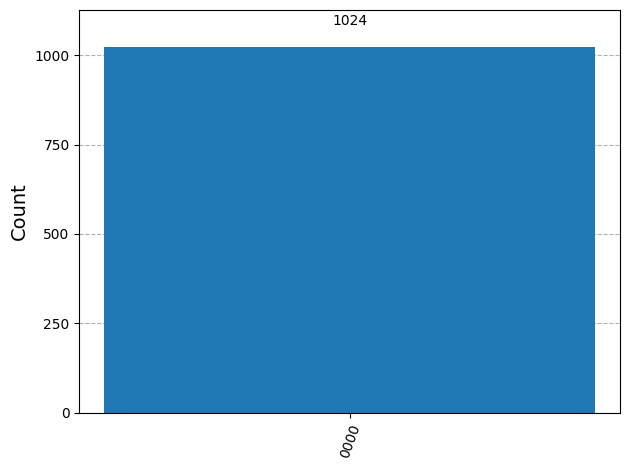

In [11]:
plot_histogram(counts)

Original circuit qubits: 65
Decomposed gate counts: OrderedDict({'sx': 208, 'cz': 116, 'rz': 56, 'measure': 4, 'barrier': 2, 'x': 1})
Running with noise model from FakeFez (156 qubits)




In [12]:
# =============================================================================
# NOISY SIMULATION (Proper Noise Application)
# =============================================================================
# CRITICAL: Transpile to FakeFez basis gates so noise model applies correctly!
# - basis_gates only (no backend) = no coupling map or qubit count constraints
# - SWAP → 3 CZ + 6 SX gates, all with noise defined

noisy_simulator = AerSimulator(
    noise_model=network_channel_noise,
    method='matrix_product_state'
)

# Transpile to basis gates for proper noise application
noisy_circuit = transpile(a_to_b_circuit, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)

print(f"Original circuit qubits: {a_to_b_circuit.num_qubits}")
print(f"Decomposed gate counts: {noisy_circuit.count_ops()}")
print(f"Running with noise model from FakeFez ({fake_backend.num_qubits} qubits)")
noisy_circuit.draw('mpl', fold=-1, idle_wires=False)

In [13]:
# Run noisy simulation on decomposed circuit
noisy_result = noisy_simulator.run(noisy_circuit, shots=NUM_SHOTS).result()
noisy_counts = dict(sorted(noisy_result.get_counts().items(), key=lambda x: x[0]))
print(noisy_counts)

{'0000': 874, '0001': 9, '0010': 14, '0011': 4, '0100': 19, '0101': 7, '0110': 3, '0111': 10, '1000': 19, '1001': 6, '1010': 12, '1011': 11, '1100': 6, '1101': 9, '1110': 15, '1111': 6}


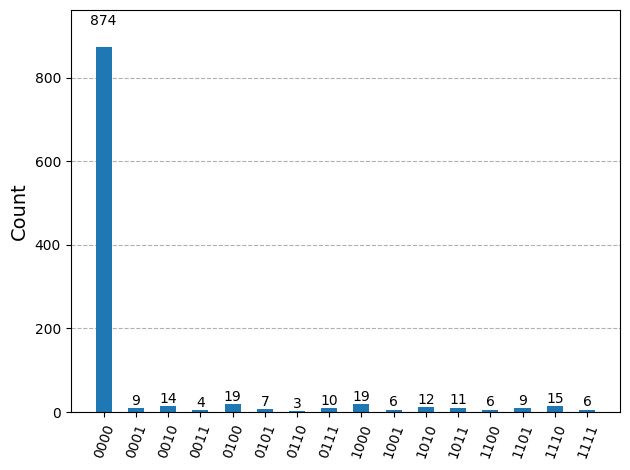

In [14]:
plot_histogram(noisy_counts)

In [15]:
class TimeAwareMeasurement:
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 16-dimensional numpy array of syndrome counts.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '313_X', '313_Z', '513'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type  # Default, will be updated per sample


# 513 Syndrome Data

In [16]:
import numpy as np

# =============================================================================
# 513 SYNDROME DATA GENERATION
# =============================================================================
# CRITICAL: Transpile to FakeFez basis gates for proper noise application!
# SWAP gates must be decomposed to CZ + SX gates which have noise defined.

EDGE_SYNDROME_DATA = {}
TIME_AWARE_MEASUREMENTS = []

# Create noisy simulator (noise model only, no coupling constraints)
NOISY_AER_SIM = AerSimulator(
    noise_model=network_channel_noise,
    method='matrix_product_state'
)

print("=" * 70)
print("513 SYNDROME DATA GENERATION")
print("=" * 70)
print(f"Simulator: AerSimulator with FakeFez noise model")
print(f"Basis gates for decomposition: {FEZ_BASIS_GATES}")
print(f"Shots per circuit: {NUM_SHOTS}")
print(f"Total paths to process: {len(ALL_HOP_PATHS)}")
print("=" * 70)

for path_idx, path in enumerate(ALL_HOP_PATHS):
    print(f"\n[{path_idx + 1}/{len(ALL_HOP_PATHS)}] Processing path: {path}")
    
    # Build circuit using physical qubit mapping
    circuit = build_multihop_swapping_circuit_syndrome_physical(path, initial_state='0')
    
    # CRITICAL: Transpile to basis gates for proper noise application
    # Using basis_gates only (no backend) avoids qubit count constraints
    decomposed_circuit = transpile(circuit, basis_gates=FEZ_BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    
    # Run noisy simulation
    noisy_result = NOISY_AER_SIM.run(decomposed_circuit, shots=NUM_SHOTS).result()
    noisy_counts = noisy_result.get_counts()
    
    # Build proper 16-element histogram with correct syndrome indexing
    histogram = np.zeros(16, dtype=np.float32)
    for syndrome_str, count in noisy_counts.items():
        idx = int(syndrome_str, 2)  # Convert binary string '0101' -> integer 5
        histogram[idx] = count
    
    # Convert node path [0, 1, 2] to edge tuples [(0, 1), (1, 2)]
    path_edges = [(path[i], path[i + 1]) for i in range(len(path) - 1)]
    
    print(f"  Path edges: {path_edges}")
    print(f"  Histogram (16 elements): {histogram}")
    print(f"  Total counts: {histogram.sum()}")
    
    # Store nodes used and their physical qubit ranges for verification
    nodes_used = path
    qubit_ranges = {n: (NODE_PHYSICAL_QUBITS[n][0], NODE_PHYSICAL_QUBITS[n][-1]) for n in nodes_used}
    print(f"  Physical qubits used: {qubit_ranges}")
    
    measurement_data = TimeAwareMeasurement(
        path_edges=path_edges,
        histogram=histogram,
        duration=0.0, 
        latency_stats={},
        code_type='513'
    )
    TIME_AWARE_MEASUREMENTS.append(measurement_data)

print(f"\n{'=' * 70}")
print(f"Total measurements collected: {len(TIME_AWARE_MEASUREMENTS)}")
print(f"{'=' * 70}")

513 SYNDROME DATA GENERATION
Simulator: AerSimulator with FakeFez noise model
Basis gates for decomposition: ['cz', 'id', 'rz', 'sx', 'x']
Shots per circuit: 1024
Total paths to process: 17

[1/17] Processing path: [0, 1]
Building circuit for path: [0, 1]
  Source: Node 0 (physical qubits 0-8)
  Sink: Node 1 (physical qubits 9-17)
  Swap edges: [(0, 1)]
  Path edges: [(0, 1)]
  Histogram (16 elements): [875.   5.  31.   6.  26.  10.   5.   3.  12.   8.   9.   5.  11.   6.
   4.   8.]
  Total counts: 1024.0
  Physical qubits used: {0: (0, 8), 1: (9, 17)}

[2/17] Processing path: [0, 1, 2]
Building circuit for path: [0, 1, 2]
  Source: Node 0 (physical qubits 0-8)
  Sink: Node 2 (physical qubits 18-26)
  Swap edges: [(0, 1), (1, 2)]
  Path edges: [(0, 1), (1, 2)]
  Histogram (16 elements): [868.  12.  19.  10.  13.  10.   5.  11.   6.  14.   8.   7.   9.   8.
  13.  11.]
  Total counts: 1024.0
  Physical qubits used: {0: (0, 8), 1: (9, 17), 2: (18, 26)}

[3/17] Processing path: [0, 3]
Bu

# Ground Truth Data

In [17]:
# =============================================================================
# GROUND TRUTH CIRCUIT (Using Physical Qubits)
# =============================================================================

def build_swapping_circuit_ground_truth_physical(source, sink, initial_state='0', measurement_basis='Z'):
    """
    Build a ground truth circuit for single-qubit transport using physical qubit indices.
    
    This circuit transports a single (unencoded) qubit from source to sink
    and measures in the specified basis to determine error rates.
    
    Args:
        source: Source node ID (0-5)
        sink: Sink node ID (0-5)
        initial_state: '0' or '1'
        measurement_basis: 'X', 'Y', or 'Z'
    
    Returns:
        QuantumCircuit with physical qubit assignments
    """
    # Get physical qubit indices
    source_qubits = NODE_PHYSICAL_QUBITS[source]
    sink_qubits = NODE_PHYSICAL_QUBITS[sink]
    
    # Get path qubit(s) for this edge
    edge_key = (min(source, sink), max(source, sink))
    path_qubits = PATH_PHYSICAL_QUBITS[edge_key]
    
    # Create circuit
    qc = QuantumCircuit(TOTAL_QUBITS)
    
    # Data qubit is at index 4 within each node's allocation
    source_qubit = source_qubits[4]
    sink_qubit = sink_qubits[4]
    
    # Prepare initial state
    if initial_state == '1':
        qc.x(source_qubit)

    # Rotate to measurement basis if needed
    if measurement_basis == 'X':
        qc.h(source_qubit)
    elif measurement_basis == 'Y':
        qc.h(source_qubit)        
        qc.s(source_qubit)

    # Swapping path from source to sink
    num_path_qubits = len(path_qubits)
    qc.swap(source_qubit, path_qubits[0])
    for j in range(num_path_qubits - 1):
        qc.swap(path_qubits[j], path_qubits[j + 1])
    qc.swap(path_qubits[num_path_qubits - 1], sink_qubit)
    
    # Add classical register for measurement
    creg = ClassicalRegister(1, name='c_data')
    qc.add_register(creg)

    # Rotate back before measurement
    if measurement_basis == 'X':
        qc.h(sink_qubit)
    elif measurement_basis == 'Y':
        qc.sdg(sink_qubit)
        qc.h(sink_qubit)    

    qc.measure(sink_qubit, creg[0])

    return qc

Ground truth circuit: Node 0 -> Node 1
  Source data qubit: 4
  Sink data qubit: 13
  Path qubit: [54, 55]


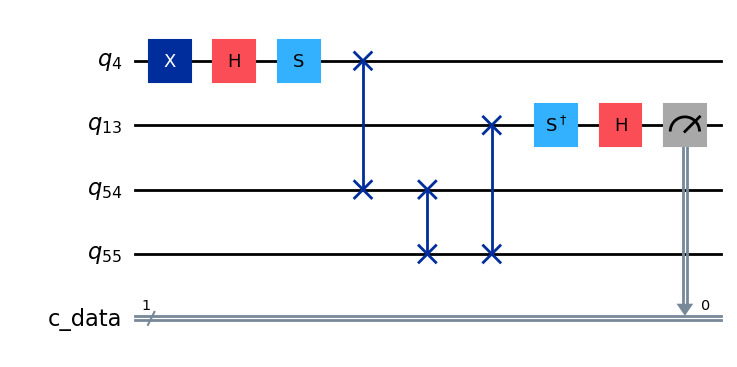

In [18]:
# Test ground truth circuit with physical qubits
a_to_b_circuit = build_swapping_circuit_ground_truth_physical(0, 1, measurement_basis='Y', initial_state='1')
print(f"Ground truth circuit: Node 0 -> Node 1")
print(f"  Source data qubit: {NODE_PHYSICAL_QUBITS[0][4]}")
print(f"  Sink data qubit: {NODE_PHYSICAL_QUBITS[1][4]}")
print(f"  Path qubit: {PATH_PHYSICAL_QUBITS[(0, 1)]}")
a_to_b_circuit.draw('mpl', fold=-1, idle_wires=False)

Circuit qubits: 65
Decomposed gate counts: OrderedDict({'sx': 20, 'cz': 9, 'rz': 6, 'x': 1, 'measure': 1})


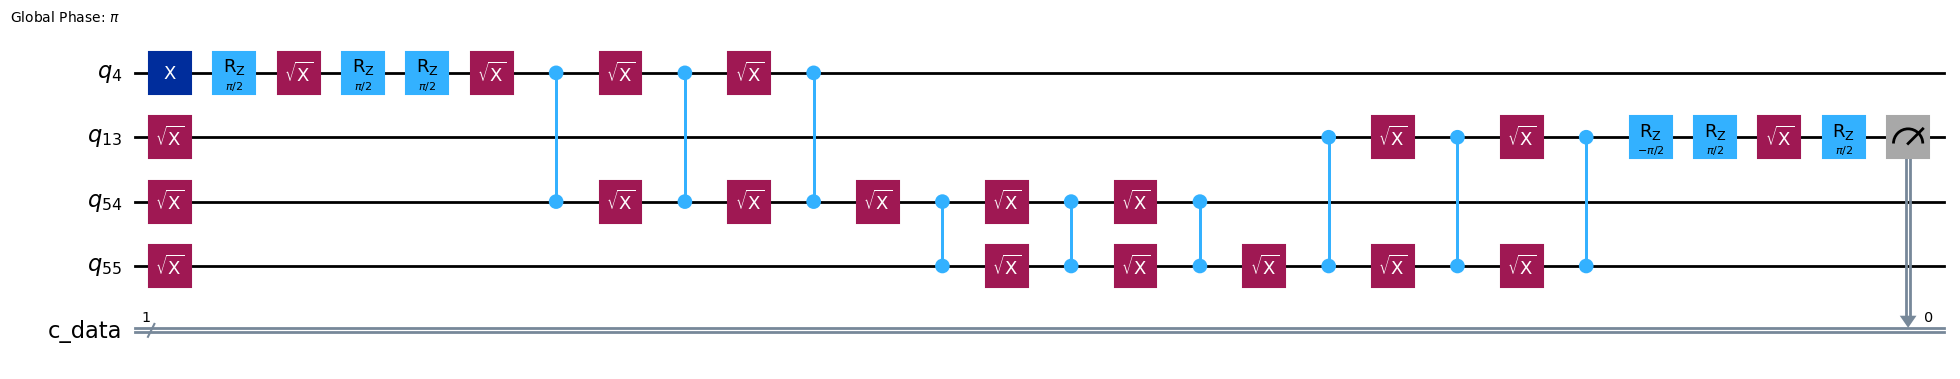

In [19]:
# Transpile to basis gates for proper noise application
decomposed_gt_circuit = transpile(a_to_b_circuit, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
print(f"Circuit qubits: {decomposed_gt_circuit.num_qubits}")
print(f"Decomposed gate counts: {decomposed_gt_circuit.count_ops()}")
decomposed_gt_circuit.draw('mpl', fold=-1, idle_wires=False)

In [20]:
# Run decomposed circuit on noisy simulator
noisy_result = noisy_simulator.run(decomposed_gt_circuit, shots=4096).result()
noisy_counts = dict(sorted(noisy_result.get_counts().items(), key=lambda x: x[0]))
print(noisy_counts)

{'0': 78, '1': 4018}


In [21]:
from typing import Dict


def calculate_exact_pauli_rates(
    z_basis_counts: Dict[str, int],
    x_basis_counts: Dict[str, int],
    y_basis_counts: Dict[str, int],
    expected_state: str = '0'
) -> Dict[str, float]:
    """
    Calculate exact X, Y, and Z error rates using full quantum state tomography.
    
    Requires three independent measurement runs in different bases to solve
    the system of equations for Pauli error probabilities.
    
    Theory:
        - Z-basis measurement detects: E_z = P(X) + P(Y)
        - X-basis measurement detects: E_x = P(Z) + P(Y)
        - Y-basis measurement detects: E_y = P(X) + P(Z)
    
    Solving this system:
        P(X) = (E_z + E_y - E_x) / 2
        P(Y) = (E_z + E_x - E_y) / 2
        P(Z) = (E_x + E_y - E_z) / 2
    
    Args:
        z_basis_counts: Measurement counts from Z-basis run (detects X and Y errors)
                       e.g., {'0': 850, '1': 50}
        x_basis_counts: Measurement counts from X-basis run (detects Z and Y errors)
                       e.g., {'0': 820, '1': 60}
        y_basis_counts: Measurement counts from Y-basis run (detects X and Z errors)
                       e.g., {'0': 800, '1': 70}
        expected_state: Expected outcome without errors ('0' or '1')
    
    Returns:
        Dictionary with exact error rates:
        {
            'PX': float,  # X error probability
            'PY': float,  # Y error probability
            'PZ': float,  # Z error probability
            'E_z': float, # Raw Z-basis error rate
            'E_x': float, # Raw X-basis error rate
            'E_y': float, # Raw Y-basis error rate
            'total_shots': dict
        }
    """
    
    def get_error_rate(counts: Dict[str, int], correct_label: str) -> float:
        """Calculate the total error rate for a measurement basis."""
        total_shots = sum(counts.values())
        if total_shots == 0:
            return 0.0
        
        correct_shots = counts.get(correct_label, 0)
        return 1.0 - (correct_shots / total_shots)
    
    # Calculate observed error rates in each basis
    E_z = get_error_rate(z_basis_counts, expected_state)  # P(X) + P(Y)
    E_x = get_error_rate(x_basis_counts, expected_state)  # P(Z) + P(Y)
    E_y = get_error_rate(y_basis_counts, expected_state)  # P(X) + P(Z)
    
    # Solve the system of linear equations
    px = 0.5 * (E_z + E_y - E_x)
    py = 0.5 * (E_z + E_x - E_y)
    pz = 0.5 * (E_x + E_y - E_z)
    
    # Clean up small negatives due to statistical noise
    return {
        'p_x': max(0.0, px),
        'p_y': max(0.0, py),
        'p_z': max(0.0, pz),
        'E_z': E_z,
        'E_x': E_x,
        'E_y': E_y,
        'total_shots': {
            'z_basis': sum(z_basis_counts.values()),
            'x_basis': sum(x_basis_counts.values()),
            'y_basis': sum(y_basis_counts.values())
        }
    }



In [22]:
# =============================================================================
# GROUND TRUTH DATA GENERATION
# =============================================================================
# Generate Pauli error rates for each edge using physical qubit mapping
# CRITICAL: Transpile to basis gates for proper noise application!

GROUND_TRUTH_DATA = {}

print("=" * 70)
print("GROUND TRUTH DATA GENERATION")
print("=" * 70)
print(f"Using physical qubit mapping with basis gate decomposition")
print(f"Basis gates: {FEZ_BASIS_GATES}")
print(f"Edges to process: {list(network_graph.edges())}")
print("=" * 70)

for edge in network_graph.edges():
    print(f"\nEdge {edge}:")
    print(f"  Source qubits: {NODE_PHYSICAL_QUBITS[edge[0]][0]}-{NODE_PHYSICAL_QUBITS[edge[0]][-1]}")
    print(f"  Sink qubits: {NODE_PHYSICAL_QUBITS[edge[1]][0]}-{NODE_PHYSICAL_QUBITS[edge[1]][-1]}")
    
    # Build circuits using physical qubit mapping
    circuit_Z = build_swapping_circuit_ground_truth_physical(edge[0], edge[1], measurement_basis='Z')
    circuit_X = build_swapping_circuit_ground_truth_physical(edge[0], edge[1], measurement_basis='X')
    circuit_Y = build_swapping_circuit_ground_truth_physical(edge[0], edge[1], measurement_basis='Y')

    # CRITICAL: Transpile to basis gates for proper noise application
    decomposed_Z = transpile(circuit_Z, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
    decomposed_X = transpile(circuit_X, basis_gates=FEZ_BASIS_GATES, optimization_level=0)
    decomposed_Y = transpile(circuit_Y, basis_gates=FEZ_BASIS_GATES, optimization_level=0)

    print("  Running Z-basis measurement...", end=' | ')
    counts_Z = dict(sorted(NOISY_AER_SIM.run(decomposed_Z, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))
    print("Running X-basis measurement...", end=' | ')
    counts_X = dict(sorted(NOISY_AER_SIM.run(decomposed_X, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))
    print("Running Y-basis measurement...")
    counts_Y = dict(sorted(NOISY_AER_SIM.run(decomposed_Y, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))

    error_rates = calculate_exact_pauli_rates(
        z_basis_counts=counts_Z,
        x_basis_counts=counts_X,
        y_basis_counts=counts_Y,
        expected_state='0'
    )

    GROUND_TRUTH_DATA[edge] = [error_rates['p_x'], error_rates['p_y'], error_rates['p_z']]
    print(f"  Pauli Errors: PX={error_rates['p_x']:.6f}, PY={error_rates['p_y']:.6f}, PZ={error_rates['p_z']:.6f}")
    print(f"  Raw error rates: E_x={error_rates['E_x']:.6f}, E_y={error_rates['E_y']:.6f}, E_z={error_rates['E_z']:.6f}")

print(f"\n{'=' * 70}")
print("Ground truth data collection complete")
print(f"{'=' * 70}")

GROUND TRUTH DATA GENERATION
Using physical qubit mapping with basis gate decomposition
Basis gates: ['cz', 'id', 'rz', 'sx', 'x']
Edges to process: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]

Edge (0, 1):
  Source qubits: 0-8
  Sink qubits: 9-17
  Running Z-basis measurement... | Running X-basis measurement... | Running Y-basis measurement...
  Pauli Errors: PX=0.003418, PY=0.017090, PZ=0.009277
  Raw error rates: E_x=0.026367, E_y=0.012695, E_z=0.020508

Edge (0, 3):
  Source qubits: 0-8
  Sink qubits: 27-35
  Running Z-basis measurement... | Running X-basis measurement... | Running Y-basis measurement...
  Pauli Errors: PX=0.005859, PY=0.003906, PZ=0.005859
  Raw error rates: E_x=0.009766, E_y=0.011719, E_z=0.009766

Edge (1, 2):
  Source qubits: 9-17
  Sink qubits: 18-26
  Running Z-basis measurement... | Running X-basis measurement... | Running Y-basis measurement...
  Pauli Errors: PX=0.010742, PY=0.010742, PZ=0.004883
  Raw error rates: E_x=0.015625, E_y=0.015625, 

In [23]:
import os
import pickle

DATA_DIR = '../../pickle_files/syndrome_data_513/'
os.makedirs(DATA_DIR, exist_ok=True)
with open(os.path.join(DATA_DIR, 'measurements.pkl'), 'wb') as f:
    pickle.dump(TIME_AWARE_MEASUREMENTS, f)

with open(os.path.join(DATA_DIR, 'ground_truth.pkl'), 'wb') as f:
    pickle.dump(GROUND_TRUTH_DATA, f)

with open(os.path.join(DATA_DIR, 'graph.pkl'), 'wb') as f:
    pickle.dump(network_graph, f)